In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import TomekLinks

In [3]:
# Load dataset
df = pd.read_excel('RFLFSODataFull.xlsx')

In [5]:
synop_counts = df['SYNOPCode'].value_counts()
print(synop_counts)

0    56964
6    25018
5     6605
8     1716
4      466
7      419
3      191
Name: SYNOPCode, dtype: int64


In [ ]:
#conda install -c conda-forge scikit-learn imbalanced-learn

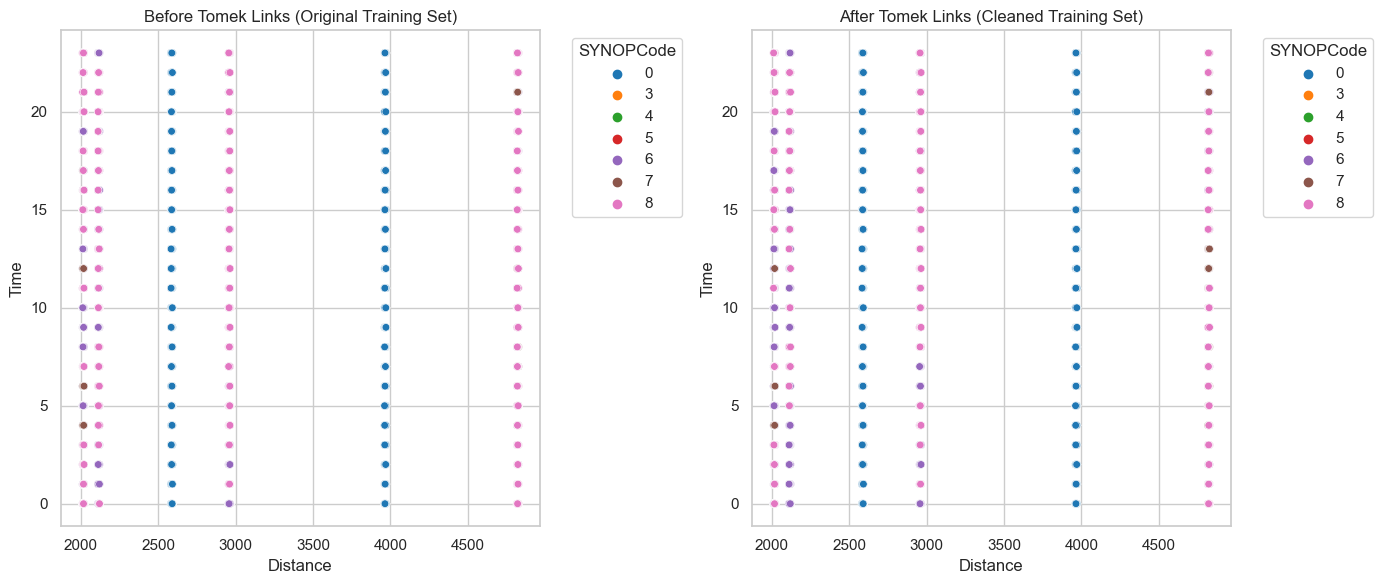

In [3]:

# Ensure necessary columns
assert all(col in df.columns for col in ['Distance', 'Time', 'SYNOPCode', 'Frequency']), "Missing required columns."

# Step 1: 70-30 train-test split per SYNOPCode
train_list, test_list = [], []

for code, group in df.groupby('SYNOPCode'):
    train_part, test_part = train_test_split(group, test_size=0.3, random_state=42)
    train_list.append(train_part)
    test_list.append(test_part)

train_df = pd.concat(train_list).reset_index(drop=True)
test_df = pd.concat(test_list).reset_index(drop=True)

# Step 2: Apply Tomek Links (based on Distance & Time only)
X_tomek = train_df[['Distance', 'Time','Frequency']]
y_tomek = train_df['SYNOPCode']

tl = TomekLinks()
X_cleaned, y_cleaned = tl.fit_resample(X_tomek, y_tomek)

# Step 3: Retrieve full rows with all features
# Match cleaned rows back to the original training data
matched_idx = train_df.set_index(['Distance', 'Time', 'Frequency']).index.isin(X_cleaned.set_index(['Distance', 'Time', 'Frequency']).index)
cleaned_train_df = train_df[matched_idx].reset_index(drop=True)

# Step 4: Visualization
plt.figure(figsize=(14, 6))
sns.set(style="whitegrid")

# Before
plt.subplot(1, 2, 1)
sns.scatterplot(data=train_df, x='Distance', y='Time', hue='SYNOPCode', palette='tab10', s=30)
plt.title("Before Tomek Links (Original Training Set)")
plt.xlabel("Distance")
plt.ylabel("Time")
plt.legend(title="SYNOPCode", bbox_to_anchor=(1.05, 1), loc='upper left')

# After
plt.subplot(1, 2, 2)
sns.scatterplot(data=cleaned_train_df, x='Distance', y='Time', hue='SYNOPCode', palette='tab10', s=30)
plt.title("After Tomek Links (Cleaned Training Set)")
plt.xlabel("Distance")
plt.ylabel("Time")
plt.legend(title="SYNOPCode", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [5]:
cleaned_train_df

,FSO_Att,RFL_Att,AbsoluteHumidity,AbsoluteHumidityMax,AbsoluteHumidityMin,Distance,Frequency,Particulate,ParticulateMax,ParticulateMin,...,TemperatureMax,TemperatureMin,Time,Visibility,VisibilityMax,VisibilityMin,WindDirection,WindSpeed,WindSpeedMax,WindSpeedMin
0,8.480261,9.694687,15.930662,17.504117,15.322833,2959.931772,73500000000,0.000000,0.000000,0.000000,...,23.615676,21.173420,10,50251.391340,52745.193251,47764.908850,84.421790,0.057545,0.462188,0.055872
1,3.511600,11.336494,4.884168,5.139645,4.514668,2018.767588,73500000000,0.000000,0.000000,0.000000,...,16.687616,15.251449,11,19554.715500,19854.670076,18626.944712,95.589421,0.000000,1.720969,0.000000
2,6.058910,10.266708,21.586978,22.967831,20.407107,2956.858380,73500000000,0.000000,0.000000,0.000000,...,28.518049,26.583940,22,15287.325520,16669.585430,14027.718822,91.561005,0.676281,1.113779,0.615111
3,6.593463,11.443969,4.074320,4.186823,3.917267,4818.176068,73500000000,0.000000,0.000000,0.000000,...,2.824572,2.434717,12,25159.573780,25252.272628,24293.881091,32.930082,0.110289,0.175660,0.105458
4,6.801351,8.726055,17.840132,19.071630,16.777477,2955.199128,73500000000,0.000000,0.000000,0.000000,...,29.207603,24.685737,3,30345.736030,33269.672010,28258.151377,95.750686,0.221128,1.290878,0.210291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42859,5.450631,13.686893,5.437567,5.841524,5.431575,4825.841905,83500000000,16.957986,18.215495,15.876605,...,5.817576,5.462535,5,27589.122520,29515.848890,27059.715033,91.460178,0.000000,3.339221,0.000000
42860,8.562129,5.726912,18.646348,20.202120,17.269297,2115.649872,73500000000,27.278849,28.111408,25.549803,...,23.635898,20.526191,22,12247.857120,13280.793041,12142.272075,100.335047,0.692477,1.564934,0.668976
42861,5.831768,13.166719,11.384310,11.686584,11.054054,2018.153150,73500000000,174.912616,188.515642,172.608997,...,15.285942,13.906865,0,7879.930898,8428.066276,7303.756801,106.176817,0.092167,0.170267,0.083516
42862,4.798019,13.244202,5.938114,6.182977,5.461478,4819.435242,73500000000,5.954184,5.964829,5.790368,...,7.448264,6.373556,15,74106.624310,77990.816742,72244.986530,98.457790,0.039269,0.174291,0.037609


In [7]:
synop_counts = cleaned_train_df['SYNOPCode'].value_counts()
print(synop_counts)

0    30610
6     9629
5     1844
8      423
3      133
4      125
7      100
Name: SYNOPCode, dtype: int64


In [ ]:
cleaned_train_df.to_excel("train_dataset.xlsx", index=False)

In [9]:
test_df

,FSO_Att,RFL_Att,AbsoluteHumidity,AbsoluteHumidityMax,AbsoluteHumidityMin,Distance,Frequency,Particulate,ParticulateMax,ParticulateMin,...,TemperatureMax,TemperatureMin,Time,Visibility,VisibilityMax,VisibilityMin,WindDirection,WindSpeed,WindSpeedMax,WindSpeedMin
0,6.857219,5.069489,14.682099,15.717176,14.664532,2961.886251,73500000000,0.000000,0.000000,0.000000,...,19.979123,17.557490,21,45857.443250,48768.845558,44225.348173,52.521247,0.471960,1.025758,0.457783
1,11.686944,12.659372,7.858811,8.390548,7.757759,2585.229227,83500000000,0.000000,0.000000,0.000000,...,19.562956,17.639011,12,36284.477600,37503.198582,35626.175016,92.816494,3.384595,6.388252,3.279724
2,9.375230,3.734785,9.057397,9.253028,9.012814,2958.820370,83500000000,0.000000,0.000000,0.000000,...,18.524791,15.877571,13,64350.111100,64384.177940,59348.996852,83.405317,0.000000,0.090859,0.000000
3,4.864496,11.203769,3.647547,3.821812,3.572852,4820.483790,73500000000,0.000000,0.000000,0.000000,...,6.267305,5.436820,12,74995.192040,78609.932555,73574.396183,103.716825,0.147505,0.301495,0.144998
4,4.064052,12.818626,7.059999,7.533748,6.551670,4826.974011,83500000000,0.000000,0.000000,0.000000,...,6.711993,5.813281,2,5322.886654,5664.386291,5189.554847,34.894296,0.000000,0.039788,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27412,7.102467,9.423831,19.814061,21.788366,18.782450,2963.246753,83500000000,16.180712,17.791450,15.426239,...,25.334012,23.820605,14,21916.369070,22496.148276,21497.228105,116.169528,0.000000,0.959009,0.000000
27413,10.375335,10.230216,17.024001,18.206145,15.689054,2960.394346,73500000000,122.209701,133.560174,121.928563,...,23.447278,20.346678,17,7406.235283,7889.060774,7042.703026,96.241321,0.187595,1.846748,0.184513
27414,3.031405,12.818041,6.926989,7.345989,6.883141,4818.874250,73500000000,0.000000,0.000000,0.000000,...,9.374115,8.630269,7,75002.766110,77095.169493,69286.615566,98.527337,0.511202,2.390475,0.483723
27415,3.686658,15.335383,12.903502,13.089438,12.409074,2021.996199,83500000000,31.872740,33.175205,31.214613,...,17.814613,17.181478,23,7489.549857,7548.019579,7132.264901,87.537602,1.175298,5.134773,1.121277


In [11]:
test_df.to_excel("test_dataset.xlsx", index=False)